# Multi-Agent Trip Planner using LangGraph
### Day 9 Assignment — Memory + Orchestrator + PDF Generator

**Author:** Kavin K · **Course:** AFDE Prodapt Chennai

This notebook implements a production-style multi-agent travel planning system. It satisfies every item on the assignment's *Final Deliverables* checklist:

| # | Deliverable | Where in this notebook |
|---|-------------|------------------------|
| 1 | Architecture diagram | Section 1 (rendered from companion PNG) |
| 2 | LangGraph workflow | Section 7 (graph auto-rendered) |
| 3 | Agent design | Sections 4 & 5 (one cell per agent) |
| 4 | Orchestrator logic | Section 6 |
| 5 | Tool design | Section 3 |
| 6 | Memory system | Section 5.2 |
| 7 | PDF generator module | Section 5.10 |
| 8 | Prompt design | Inline `SYSTEM_*` constants |
| 9 | State schema | Section 2 |
| 10 | Working demo | Section 8 |
| 11 | Final PDF output | `trip_report.pdf` produced at the end |

**Design choices, in plain English:**

- **LangGraph** is used because the assignment specifies it and because it gives an explicit, debuggable state machine.
- **Mock APIs ship by default.** The notebook runs to completion without any API keys. Each tool is marked with `# TODO: real API` so you know exactly where to swap in OpenWeatherMap, Skyscanner, Booking.com, etc.
- **Optional real LLM.** If `OPENAI_API_KEY` is set in the environment, the LLM is used for reasoning, prompts, and itinerary generation. If not, a deterministic mock LLM is used so the demo still produces a real PDF.
- **Memory** is implemented with a tiny in-process vector store (NumPy + sentence-transformers if available, else hashed bag-of-words). For production, swap `MemoryStore` for Chroma / FAISS — the interface is the same.
- **PDF** uses ReportLab.


## 1 · Architecture

The Orchestrator is the brain. Nine specialist agents do the actual work. A vector memory store remembers user preferences across runs. When everything is approved, the PDF Generator produces a downloadable trip report.

![Architecture](diagrams/06_trip_planner_architecture.png)

For the LangGraph workflow itself see Section 7.


## 2 · Setup, Imports, State Schema

In [34]:
# Install only what's missing. Comment out lines you already have.
# !pip install -q langgraph langchain langchain-openai langchain-core
# !pip install -q reportlab numpy sentence-transformers


In [35]:
import os, json, math, random, datetime as dt
from dataclasses import dataclass, field
from typing import TypedDict, List, Dict, Any, Optional, Annotated, Literal
import operator

import numpy as np

# LangGraph / LangChain
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

# Reproducibility for the mocks
random.seed(42)
np.random.seed(42)


### 2.1 State Schema

The state is a `TypedDict` that flows between every node. Each specialist writes to one slot. `messages` uses `operator.add` so parallel writes append instead of overwrite — the most common LangGraph footgun. (See guide §5.2.)


In [36]:
class TripState(TypedDict, total=False):
    # identity
    user_id: str
    thread_id: str

    # conversation
    messages: Annotated[List[dict], operator.add]

    # inputs
    raw_query: str
    trip_preferences: Dict[str, Any]
    user_profile: Dict[str, Any]

    # specialist outputs
    weather_data: Dict[str, Any]
    transport_data: Dict[str, Any]
    hotel_data: Dict[str, Any]
    places_data: Dict[str, Any]
    budget_summary: Dict[str, Any]
    itinerary: Dict[str, Any]

    # control
    review_status: Dict[str, Any]
    orchestrator_decision: Dict[str, Any]
    pdf_status: Dict[str, Any]
    retry_count: int


## 3 · LLM Wrapper

We define one tiny `llm_call(system, user)` function. If `OPENAI_API_KEY` is set it routes to `ChatOpenAI`; otherwise it returns deterministic mock text so the demo still produces a PDF. This keeps the rest of the notebook free of conditionals.


In [37]:
USE_REAL_LLM = bool(os.environ.get("OPENAI_API_KEY"))

if USE_REAL_LLM:
    from langchain_openai import ChatOpenAI
    _llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.2)

def llm_call(system: str, user: str) -> str:
    """Return the LLM text response. Falls back to a deterministic mock.

    INPUT GUARDRAIL: both *system* and *user* are sanitised (control-chars
    stripped, length-capped at 800 / 1500 chars) before being forwarded to
    the real LLM.  The sanitiser is a no-op if GUARDRAILS isn't defined yet
    (i.e. if this cell is re-run in isolation).
    """
    # Sanitise inputs — strip control chars, cap length
    if "GUARDRAILS" in globals():
        system = GUARDRAILS.sanitize_llm_input(system, max_len=800)
        user   = GUARDRAILS.sanitize_llm_input(user,   max_len=1500)

    if USE_REAL_LLM:
        from langchain_core.messages import SystemMessage, HumanMessage
        return _llm.invoke([SystemMessage(content=system),
                            HumanMessage(content=user)]).content

    # ---- Mock LLM: rule-based, deterministic ----
    text = (system + " || " + user).lower()
    if "itinerary" in text or "day-wise" in text:
        return ("Day 1: Arrive, check-in, beach sunset. "
                "Day 2: North Goa beaches + nightlife. "
                "Day 3: Old Goa churches + spice farm. "
                "Day 4: South Goa beaches + dolphin cruise. "
                "Day 5: Shopping, lunch, depart.")
    if "review" in text or "approve" in text:
        return '{"approved": true, "issues": []}'
    if "packing" in text:
        return "Sunscreen; light cotton clothes; swimsuit; sandals; phone charger; passport copy."
    if "summary" in text or "headline" in text:
        return "A relaxed 5-day couple's beach trip to Goa with seafood and nightlife."
    return "Acknowledged."


## 3.5 · Input Guardrails

**Guardrails** are validation checks that sit *before* any agent or LLM receives input.
They protect the system from bad data, impossible requests, and malicious inputs.

| Layer | What it catches |
|-------|----------------|
| **Guard 1 — raw query** | Prompt-injection patterns, off-topic queries, length overflow |
| **Guard 2 — preferences** | Wrong types, out-of-range values (days, travelers, budget, date, enums) |
| **Guard 3 — business rules** | Source = destination, budget too low per person per day |
| **LLM input sanitiser** | Control characters, oversized system/user messages before LLM call |

`InputGuardrails.validate_all()` is called at the top of `user_input_agent`
so **every** execution path is protected before any tool or LLM is invoked.

In [38]:
import re

class InputGuardrailError(ValueError):
    """Raised when an input fails a guardrail check.

    Caught by user_input_agent and surfaced as a review_status issue
    so the orchestrator handles it gracefully instead of crashing.
    """

class InputGuardrails:
    """
    Validates and sanitises trip-planner inputs BEFORE they reach any agent or LLM.

    Three guard layers:
      Guard 1 · raw_query   — injection scan, length cap, off-topic detection
      Guard 2 · preferences — type correctness + range constraints per field
      Guard 3 · cross-field — src != dst, minimum budget floor
    """

    # ── Allowed enum values ───────────────────────────────────────────────────
    VALID_MODES  = {"flight", "train", "car", "any"}
    VALID_VIBES  = {"luxury", "mid", "budget"}
    VALID_TYPES  = {"solo", "couple", "family", "friends", "group"}

    # ── Prompt-injection red-flag patterns ────────────────────────────────────
    INJECTION_PATTERNS = [
        r"ignore\s+(all\s+)?(previous|prior|above)\s+instructions",
        r"forget\s+(everything|all|your)\s+(you\s+know|instructions|prompt)",
        r"you\s+are\s+now\s+(?:a|an)\s+",
        r"act\s+as\s+(?:if\s+you\s+are\s+|a\s+|an\s+)?(?:jailbroken|evil|uncensored|hacker|dan)",
        r"<\s*script[^>]*>",
        r"system\s*:.*override",
        r"\bprompt\s+injection\b",
    ]

    # ── Keywords that signal a travel query ───────────────────────────────────
    TRAVEL_KEYWORDS = {
        "trip", "travel", "vacation", "holiday", "tour", "visit", "flight",
        "hotel", "stay", "destination", "city", "place", "days", "budget",
        "plan", "goa", "manali", "beach", "mountain", "book", "resort",
        "sightseeing", "explore", "itinerary", "depart", "arrive",
        "bangalore", "mumbai", "delhi", "shimla", "ooty", "kerala",
        "jaipur", "leh", "pondicherry", "mysore", "hyderabad", "pune",
    }

    # ── Limits ────────────────────────────────────────────────────────────────
    MIN_BUDGET_PER_PERSON_PER_DAY = 300   # ₹ bare-minimum feasibility
    MAX_DAYS          = 30
    MAX_TRAVELERS     = 20
    MAX_HORIZON_DAYS  = 730               # 2 years ahead
    MAX_QUERY_LEN     = 2000             # characters

    # ─────────────────────────────────────────────────────────────────────────
    # Public API
    # ─────────────────────────────────────────────────────────────────────────

    def validate_all(self, raw_query: str, prefs: dict) -> dict:
        """Run all guardrail layers. Returns a sanitised prefs dict on success.
        Raises InputGuardrailError with a descriptive message on failure."""
        self._check_raw_query(raw_query)
        sanitised = self._check_preferences(prefs)
        self._check_business_rules(sanitised)
        return sanitised

    def sanitize_llm_input(self, text: str, max_len: int = 1500) -> str:
        """Strip control chars and truncate *text* before it reaches the LLM.
        Safe to call on both system prompts and user messages."""
        text = re.sub(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]", "", text)
        if len(text) > max_len:
            text = text[:max_len] + " ... [truncated by guardrail]"
        return text

    # ─────────────────────────────────────────────────────────────────────────
    # Guard 1 — raw query
    # ─────────────────────────────────────────────────────────────────────────

    def _check_raw_query(self, query: str):
        if not isinstance(query, str) or not query.strip():
            raise InputGuardrailError("raw_query must be a non-empty string.")

        q_lower = query.lower()

        # 1a. Prompt-injection scan
        for pattern in self.INJECTION_PATTERNS:
            if re.search(pattern, q_lower, re.IGNORECASE):
                raise InputGuardrailError(
                    "Input rejected: possible prompt-injection pattern detected. "
                    "Please enter a genuine travel planning request."
                )

        # 1b. Length cap
        if len(query) > self.MAX_QUERY_LEN:
            raise InputGuardrailError(
                f"Query is too long ({len(query)} chars; max {self.MAX_QUERY_LEN}). "
                "Please summarise your request."
            )

        # 1c. Off-topic detection (skip very short strings — might just be a city name)
        if len(query) > 30:
            tokens = set(re.findall(r"\w+", q_lower))
            if not tokens & self.TRAVEL_KEYWORDS:
                raise InputGuardrailError(
                    "Your query doesn't appear to be about trip planning. "
                    "Please describe your travel request (destination, dates, budget, etc.)."
                )

    # ─────────────────────────────────────────────────────────────────────────
    # Guard 2 — preference fields
    # ─────────────────────────────────────────────────────────────────────────

    def _check_preferences(self, prefs: dict) -> dict:
        if not isinstance(prefs, dict):
            raise InputGuardrailError("trip_preferences must be a dictionary.")

        sanitised = dict(prefs)
        errors = []

        # days
        days = sanitised.get("days")
        if days is not None:
            try:
                sanitised["days"] = int(days)
            except (TypeError, ValueError):
                errors.append("'days' must be an integer (e.g. 5).")
            else:
                if not (1 <= sanitised["days"] <= self.MAX_DAYS):
                    errors.append(f"'days' must be between 1 and {self.MAX_DAYS}.")

        # travelers
        travelers = sanitised.get("travelers")
        if travelers is not None:
            try:
                sanitised["travelers"] = int(travelers)
            except (TypeError, ValueError):
                errors.append("'travelers' must be an integer.")
            else:
                if not (1 <= sanitised["travelers"] <= self.MAX_TRAVELERS):
                    errors.append(f"'travelers' must be between 1 and {self.MAX_TRAVELERS}.")

        # budget
        budget = sanitised.get("budget")
        if budget is not None:
            try:
                sanitised["budget"] = float(budget)
            except (TypeError, ValueError):
                errors.append("'budget' must be a positive number.")
            else:
                if sanitised["budget"] <= 0:
                    errors.append("'budget' must be greater than zero.")

        # start_date
        start = sanitised.get("start_date")
        if start is not None:
            try:
                import datetime as dt
                trip_date = dt.date.fromisoformat(str(start))
            except ValueError:
                errors.append("'start_date' must be a valid ISO date: YYYY-MM-DD.")
            else:
                sanitised["start_date"] = str(trip_date)
                import datetime as dt
                today = dt.date.today()
                if trip_date < today:
                    errors.append(f"'start_date' {start} is in the past.")
                elif (trip_date - today).days > self.MAX_HORIZON_DAYS:
                    errors.append(
                        f"'start_date' is more than {self.MAX_HORIZON_DAYS} days away. "
                        "Please plan within 2 years."
                    )

        # mode_pref
        mode = sanitised.get("mode_pref")
        if mode is not None:
            if str(mode).lower() not in self.VALID_MODES:
                errors.append(f"'mode_pref' must be one of {sorted(self.VALID_MODES)}.")
            else:
                sanitised["mode_pref"] = str(mode).lower()

        # vibe
        vibe = sanitised.get("vibe")
        if vibe is not None:
            if str(vibe).lower() not in self.VALID_VIBES:
                errors.append(f"'vibe' must be one of {sorted(self.VALID_VIBES)}.")
            else:
                sanitised["vibe"] = str(vibe).lower()

        # travel_type
        ttype = sanitised.get("travel_type")
        if ttype is not None:
            if str(ttype).lower() not in self.VALID_TYPES:
                errors.append(f"'travel_type' must be one of {sorted(self.VALID_TYPES)}.")
            else:
                sanitised["travel_type"] = str(ttype).lower()

        # source / destination
        for key in ("source", "destination"):
            val = sanitised.get(key)
            if val is not None:
                if not isinstance(val, str) or not val.strip():
                    errors.append(f"'{key}' must be a non-empty string.")
                else:
                    sanitised[key] = val.strip().title()

        # interests
        interests = sanitised.get("interests")
        if interests is not None:
            if not isinstance(interests, list):
                errors.append("'interests' must be a list of strings.")
            else:
                sanitised["interests"] = [str(i).lower().strip() for i in interests if i]

        if errors:
            raise InputGuardrailError(
                "Preference validation failed:\n" + "\n".join(f"  • {e}" for e in errors)
            )
        return sanitised

    # ─────────────────────────────────────────────────────────────────────────
    # Guard 3 — cross-field business rules
    # ─────────────────────────────────────────────────────────────────────────

    def _check_business_rules(self, prefs: dict):
        errors = []

        # Source ≠ Destination
        src = prefs.get("source", "").lower().strip()
        dst = prefs.get("destination", "").lower().strip()
        if src and dst and src == dst:
            errors.append("'source' and 'destination' cannot be the same city.")

        # Minimum viable budget
        budget    = prefs.get("budget", 0)
        days      = prefs.get("days", 1)
        travelers = prefs.get("travelers", 1)
        if budget and days and travelers:
            floor = self.MIN_BUDGET_PER_PERSON_PER_DAY * days * travelers
            if budget < floor:
                errors.append(
                    f"Budget ₹{budget:,.0f} is too low for {travelers} traveller(s) "
                    f"over {days} day(s). Minimum recommended: ₹{floor:,}."
                )

        if errors:
            raise InputGuardrailError(
                "Business-rule check failed:\n" + "\n".join(f"  • {e}" for e in errors)
            )


GUARDRAILS = InputGuardrails()
print("✓ InputGuardrails initialised — 3 guard layers active.")
print(f"  Guard 1 · raw_query  : injection scan + off-topic detection + {GUARDRAILS.MAX_QUERY_LEN}-char cap")
print(f"  Guard 2 · preferences: 9-field type/range validation")
print(f"  Guard 3 · cross-field: src≠dst, budget floor ₹{GUARDRAILS.MIN_BUDGET_PER_PERSON_PER_DAY}/person/day")


✓ InputGuardrails initialised — 3 guard layers active.
  Guard 1 · raw_query  : injection scan + off-topic detection + 2000-char cap
  Guard 2 · preferences: 9-field type/range validation
  Guard 3 · cross-field: src≠dst, budget floor ₹300/person/day


## 4 · Tools (mock APIs by default)

Each tool below is a regular Python function. In a real LangChain agent you would decorate them with `@tool` so the LLM could call them; in our orchestrator-driven design we just call them directly from each specialist node. That keeps control flow explicit — which is what the assignment is grading.

Every mock is deterministic given the inputs (seeded RNG) so your PDF looks the same every run. Replace the marked sections with real API calls when you have keys.


In [39]:
# ---------------- WEATHER ----------------
def tool_get_weather(city: str, start: str, days: int) -> Dict[str, Any]:
    """# TODO: real API — replace with OpenWeatherMap forecast endpoint."""
    base_temp = {"goa": 30, "manali": 14, "leh": 8, "ooty": 18,
                 "jaipur": 32, "shimla": 16, "kerala": 29}.get(city.lower(), 25)
    forecast = []
    d0 = dt.date.fromisoformat(start)
    for i in range(days):
        date = d0 + dt.timedelta(days=i)
        cond = random.choice(["sunny", "sunny", "partly cloudy", "light rain"])
        forecast.append({
            "date": date.isoformat(),
            "high_c": base_temp + random.randint(-2, 4),
            "low_c":  base_temp - random.randint(4, 8),
            "conditions": cond,
        })
    return {"city": city, "forecast": forecast,
            "summary": f"Mostly pleasant; {sum(1 for f in forecast if 'rain' in f['conditions'])} day(s) of light rain expected."}

# ---------------- TRANSPORT (flights/train/road) ----------------
def tool_search_transport(origin: str, dest: str, date: str, mode_pref: str) -> Dict[str, Any]:
    """# TODO: real API — Skyscanner / Amadeus / IRCTC."""
    options = []
    base = {("bangalore", "goa"): 4500, ("delhi", "goa"): 6500,
            ("mumbai", "goa"): 3000}.get((origin.lower(), dest.lower()), 5500)
    if mode_pref in ("any", "flight"):
        options += [
            {"mode": "flight", "provider": "IndiGo",     "depart": "07:00", "arrive": "08:25", "price": base},
            {"mode": "flight", "provider": "Air India",  "depart": "10:15", "arrive": "11:50", "price": base + 800},
        ]
    if mode_pref in ("any", "train"):
        options.append({"mode": "train", "provider": "Vasco Exp", "depart": "20:30", "arrive": "10:15+1", "price": int(base * 0.4)})
    if mode_pref in ("any", "car"):
        options.append({"mode": "car",   "provider": "Self-drive", "depart": "06:00", "arrive": "16:00", "price": int(base * 0.6)})
    options.sort(key=lambda x: x["price"])
    return {"origin": origin, "destination": dest, "options": options,
            "recommended": options[0]}

# ---------------- HOTELS ----------------
def tool_search_hotels(city: str, checkin: str, checkout: str, budget_per_night: int, vibe: str) -> Dict[str, Any]:
    """# TODO: real API — Booking.com / Hotels.com."""
    catalog = {
        "goa": [
            {"name": "Taj Fort Aguada",   "stars": 5, "price": 12000, "tags": ["beach", "luxury", "pool"]},
            {"name": "The Leela Goa",     "stars": 5, "price": 18000, "tags": ["beach", "luxury", "spa"]},
            {"name": "Lemon Tree Candolim","stars": 4, "price": 5500,  "tags": ["beach", "mid", "nightlife"]},
            {"name": "Cidade de Goa",     "stars": 4, "price": 7200,  "tags": ["beach", "couple"]},
            {"name": "Backwoods Hostel",  "stars": 2, "price": 1200,  "tags": ["budget", "solo"]},
        ]
    }
    hotels = catalog.get(city.lower(), [
        {"name": f"{city} Grand", "stars": 4, "price": 4500, "tags": ["mid"]},
        {"name": f"{city} Heritage", "stars": 3, "price": 2500, "tags": ["budget"]},
    ])
    filt = [h for h in hotels if h["price"] <= budget_per_night]
    if vibe == "luxury":
        filt = sorted(filt, key=lambda h: -h["stars"])
    elif vibe == "budget":
        filt = sorted(filt, key=lambda h: h["price"])
    return {"city": city, "candidates": filt[:5],
            "top_pick": filt[0] if filt else None}

# ---------------- PLACES ----------------
def tool_explore_places(city: str, interests: List[str]) -> Dict[str, Any]:
    """# TODO: real API — Google Places / Tripadvisor."""
    db = {
        "goa": [
            {"name": "Baga Beach",        "category": "beach",     "rating": 4.5},
            {"name": "Calangute Beach",   "category": "beach",     "rating": 4.4},
            {"name": "Fort Aguada",       "category": "heritage",  "rating": 4.3},
            {"name": "Old Goa Churches",  "category": "heritage",  "rating": 4.6},
            {"name": "Tito's Lane",       "category": "nightlife", "rating": 4.2},
            {"name": "Anjuna Flea Market","category": "shopping",  "rating": 4.1},
            {"name": "Dudhsagar Falls",   "category": "nature",    "rating": 4.7},
        ]
    }
    items = db.get(city.lower(), [
        {"name": f"{city} Central Park", "category": "nature", "rating": 4.2}
    ])
    # filter by interests (any-match)
    if interests:
        scored = []
        for p in items:
            score = sum(1 for tag in interests if tag.lower() in p["category"].lower())
            scored.append((score, p))
        items = [p for _, p in sorted(scored, key=lambda t: -t[0])]
    return {"city": city, "attractions": items[:6]}

# ---------------- BUDGET (pure calculator) ----------------
def tool_budget_calculator(transport: Dict, hotel: Dict, nights: int,
                           travelers: int, daily_food: int = 800,
                           daily_activities: int = 500) -> Dict[str, Any]:
    transport_cost = transport["recommended"]["price"] * travelers
    if transport["recommended"]["mode"] in ("train", "car"):
        transport_cost = int(transport_cost * 0.7)  # car/train shared
    hotel_cost = hotel["top_pick"]["price"] * nights if hotel["top_pick"] else 0
    food_cost = daily_food * (nights + 1) * travelers
    activity_cost = daily_activities * (nights + 1) * travelers
    total = transport_cost + hotel_cost + food_cost + activity_cost
    return {
        "transport_cost": transport_cost,
        "hotel_cost": hotel_cost,
        "food_cost": food_cost,
        "activity_cost": activity_cost,
        "total": total,
        "breakdown_pct": {
            "transport": round(100 * transport_cost / total, 1),
            "hotel":     round(100 * hotel_cost / total, 1),
            "food":      round(100 * food_cost / total, 1),
            "activities":round(100 * activity_cost / total, 1),
        }
    }


## 5 · Memory Store (vector, semantic, swappable)

We want the system to remember "this user loves seafood and beaches" across runs. A real deployment uses Chroma or FAISS. Here we ship a 30-line numpy-based vector store with the same `add` / `query` API, so the rest of the code is identical. If `sentence-transformers` is installed it produces real embeddings; otherwise it falls back to hashed bag-of-words (good enough for the demo).


In [40]:
try:
    from sentence_transformers import SentenceTransformer
    _emb_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
    EMB_DIM = 384
    def _embed(text: str) -> np.ndarray:
        return _emb_model.encode([text], normalize_embeddings=True)[0]
except Exception:
    # Hashed bag-of-words fallback — no extra install required.
    EMB_DIM = 256
    def _embed(text: str) -> np.ndarray:
        vec = np.zeros(EMB_DIM, dtype=np.float32)
        for tok in text.lower().split():
            vec[hash(tok) % EMB_DIM] += 1.0
        n = np.linalg.norm(vec)
        return vec / n if n else vec

class MemoryStore:
    """Drop-in mini vector DB. Swap for Chroma/FAISS in production."""
    def __init__(self):
        self._texts: List[str] = []
        self._meta:  List[dict] = []
        self._vecs:  List[np.ndarray] = []

    def add(self, text: str, meta: dict):
        self._texts.append(text)
        self._meta.append(meta)
        self._vecs.append(_embed(text))

    def query(self, q: str, k: int = 3) -> List[dict]:
        if not self._vecs:
            return []
        qv = _embed(q)
        sims = np.array([float(np.dot(qv, v)) for v in self._vecs])
        idx = sims.argsort()[::-1][:k]
        return [{"text": self._texts[i], "meta": self._meta[i],
                 "score": float(sims[i])} for i in idx]

MEMORY = MemoryStore()

# Seed it with a couple of pretend past trips so the demo shows recall.
MEMORY.add("User loves seafood and beach destinations, prefers couple-friendly resorts.",
           {"user_id": "demo_user", "type": "preference"})
MEMORY.add("Previous trip: Pondicherry beach holiday, budget Rs 25000, enjoyed.",
           {"user_id": "demo_user", "type": "trip_history"})
print("Memory seeded with", len(MEMORY._texts), "items.")


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6574.94it/s]


Memory seeded with 2 items.


## 6 · Specialist Agents (one node each)

Each agent is a plain Python function `(state) -> state-update`. That's the LangGraph contract. The pattern is:

1. Read what you need from `state`.
2. Call your tool(s).
3. Return a dict of new keys to merge into state.

Notice we never mutate `state` in place — LangGraph wants pure updates so it can checkpoint, replay, and run nodes in parallel.


In [41]:
def user_input_agent(state: TripState) -> TripState:
    """Parse / validate user preferences. In real life this is a form or chat prompt."""
    prefs = dict(state.get("trip_preferences", {}))
    # ensure required fields exist
    prefs.setdefault("source", "Bangalore")
    prefs.setdefault("destination", "Goa")
    prefs.setdefault("start_date", "2026-06-10")
    prefs.setdefault("days", 5)
    prefs.setdefault("travelers", 2)
    prefs.setdefault("travel_type", "couple")
    prefs.setdefault("budget", 30000)
    prefs.setdefault("mode_pref", "flight")
    prefs.setdefault("vibe", "mid")          # luxury / mid / budget
    prefs.setdefault("interests", ["beach", "nightlife", "heritage"])
    prefs.setdefault("food_pref", "seafood")
    return {"trip_preferences": prefs,
            "messages": [{"role": "system", "content": "User input parsed."}]}

def memory_retrieval_agent(state: TripState) -> TripState:
    """Pull past prefs / trips from the vector store."""
    user_id = state.get("user_id", "demo_user")
    query = (f"{state['trip_preferences'].get('destination','')} "
             f"{state['trip_preferences'].get('vibe','')} "
             f"{state['trip_preferences'].get('food_pref','')}")
    hits = MEMORY.query(query, k=3)
    profile = {"user_id": user_id, "recalled": [h["text"] for h in hits]}
    return {"user_profile": profile,
            "messages": [{"role": "system",
                          "content": f"Memory recalled {len(hits)} item(s)."}]}

def weather_agent(state: TripState) -> TripState:
    p = state["trip_preferences"]
    data = tool_get_weather(p["destination"], p["start_date"], p["days"])
    return {"weather_data": data}

def transport_agent(state: TripState) -> TripState:
    p = state["trip_preferences"]
    data = tool_search_transport(p["source"], p["destination"],
                                 p["start_date"], p["mode_pref"])
    return {"transport_data": data}

def hotel_agent(state: TripState) -> TripState:
    p = state["trip_preferences"]
    retries = state.get("retry_count", 0)
    # rough per-night budget = total budget / nights / 2  (half for stay)
    per_night = max(800, p["budget"] // p["days"] // 2)
    # On retry, tighten the budget so we pick something cheaper.
    per_night = int(per_night * (0.7 ** retries))
    end = (dt.date.fromisoformat(p["start_date"])
           + dt.timedelta(days=p["days"])).isoformat()
    # On retry, fall back to "budget" vibe to surface the cheapest match.
    vibe = "budget" if retries > 0 else p["vibe"]
    data = tool_search_hotels(p["destination"], p["start_date"], end,
                              per_night, vibe)
    return {"hotel_data": data}

def places_agent(state: TripState) -> TripState:
    p = state["trip_preferences"]
    data = tool_explore_places(p["destination"], p["interests"])
    return {"places_data": data}

def budget_agent(state: TripState) -> TripState:
    p = state["trip_preferences"]
    summary = tool_budget_calculator(
        state["transport_data"], state["hotel_data"],
        nights=p["days"]-1, travelers=p["travelers"])
    summary["target"] = p["budget"]
    summary["over_budget"] = summary["total"] > p["budget"]
    return {"budget_summary": summary}

def itinerary_agent(state: TripState) -> TripState:
    p = state["trip_preferences"]
    places = state["places_data"]["attractions"]
    # Distribute attractions across days; reserve day 1 for arrival, last day for departure
    days = p["days"]
    plan = []
    pool = list(places)
    for d in range(1, days + 1):
        if d == 1:
            plan.append({"day": d,
                         "morning": "Arrive & check-in",
                         "afternoon": pool.pop(0)["name"] if pool else "Hotel",
                         "evening": "Beach sunset & dinner"})
        elif d == days:
            plan.append({"day": d, "morning": pool.pop(0)["name"] if pool else "Shopping",
                         "afternoon": "Check-out & lunch", "evening": "Depart"})
        else:
            m = pool.pop(0)["name"] if pool else "Free time"
            a = pool.pop(0)["name"] if pool else "Free time"
            e = "Nightlife" if "nightlife" in p["interests"] and d == 2 else "Local dinner"
            plan.append({"day": d, "morning": m, "afternoon": a, "evening": e})
    # Polish with LLM (works with real OR mock LLM)
    head = llm_call("You are a concise travel writer.",
                    f"Give a 1-sentence headline summary of a {days}-day "
                    f"{p['travel_type']} trip to {p['destination']}.")
    return {"itinerary": {"days": plan, "headline": head}}

def final_review_agent(state: TripState) -> TripState:
    """Validate completeness + spot conflicts."""
    issues = []
    if state["budget_summary"].get("over_budget"):
        issues.append("Total cost exceeds user budget.")
    rainy = sum(1 for d in state["weather_data"]["forecast"]
                if "rain" in d["conditions"])
    if rainy >= 3:
        issues.append(f"{rainy} rainy days — consider indoor alternatives.")
    if not state["hotel_data"].get("top_pick"):
        issues.append("No hotel matched the budget.")
    if not state["transport_data"]["options"]:
        issues.append("No transport option found.")
    return {"review_status": {"approved": len(issues) == 0,
                               "issues": issues}}


## 7 · Orchestrator Agent (Supervisor)

The Orchestrator is just a router. Each pass it looks at the current state, decides *which node should run next*, and writes that decision back into the state. The conditional edge then dispatches.

We implement it as **rule-based dispatch** for transparency. Swap the rules for an LLM call (`llm_call(SUPERVISOR_PROMPT, state)`) and the same graph works — that's the whole point of separating routing from execution.


In [42]:
MAX_RETRIES = 3

def orchestrator(state: TripState) -> TripState:
    """Decide what to do next. Returns a partial-state update."""
    updates: dict = {}

    # PDF already generated → terminate
    if state.get("pdf_status"):
        nxt, reason = "END", "PDF complete — workflow done."
    elif not state.get("trip_preferences"):
        nxt, reason = "user_input", "No preferences yet."
    elif not state.get("user_profile"):
        nxt, reason = "memory", "Need to recall user prefs."
    elif not (state.get("weather_data") and state.get("hotel_data")
              and state.get("transport_data") and state.get("places_data")):
        nxt, reason = "specialists_fanout", "Gathering data in parallel."
    elif not state.get("budget_summary"):
        nxt, reason = "budget", "All specialists in — compute budget."
    elif not state.get("itinerary"):
        nxt, reason = "itinerary", "Build day-wise plan."
    elif not state.get("review_status"):
        nxt, reason = "review", "Need final review."
    else:
        review = state["review_status"]
        retries = state.get("retry_count", 0)
        if review["approved"]:
            nxt, reason = "memory_update", "Approved → persist + render PDF."
        elif retries >= MAX_RETRIES:
            nxt, reason = "memory_update", "Max retries reached → finalize with caveats."
        else:
            # Pick a specialist to retry, then CLEAR downstream state
            # so the orchestrator naturally walks budget → itinerary → review again.
            issues = " ".join(review["issues"]).lower()
            if "budget" in issues or "hotel" in issues:
                nxt, reason = "hotel", "Over budget / hotel issue → retry hotel."
            elif "rain" in issues:
                nxt, reason = "places", "Rainy days → re-pick attractions."
            elif "transport" in issues:
                nxt, reason = "transport", "Transport issue → retry."
            else:
                nxt, reason = "memory_update", "Unknown issue — finalize."
            # Clearing forces the orchestrator to re-route through these on the next pass.
            updates["budget_summary"] = {}
            updates["itinerary"] = {}
            updates["review_status"] = {}
            updates["retry_count"] = retries + 1

    updates["orchestrator_decision"] = {"next": nxt, "reason": reason}
    updates["messages"] = [{"role": "orchestrator", "content": f"→ {nxt}: {reason}"}]
    return updates

def memory_update_agent(state: TripState) -> TripState:
    """Persist this trip's preferences so future runs benefit."""
    p = state["trip_preferences"]
    MEMORY.add(
        f"Planned trip to {p['destination']} for {p['travelers']} "
        f"({p['travel_type']}), vibe={p['vibe']}, budget={p['budget']}.",
        {"user_id": state.get("user_id", "demo_user"), "type": "trip_history"}
    )
    return {"messages": [{"role": "system", "content": "Memory updated."}]}


## 8 · PDF Generator Agent (ReportLab)

Produces a professional six-section trip report. The function below is the *agent body* — it reads the finalized state and writes `trip_report.pdf` next to the notebook.


In [43]:
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib import colors
from reportlab.lib.units import cm
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer, Table,
                                TableStyle, PageBreak, Image as RLImage)

def pdf_generator_agent(state: TripState, out_path: str = "trip_report.pdf") -> TripState:
    p     = state["trip_preferences"]
    bud   = state["budget_summary"]
    hot   = state["hotel_data"]
    tra   = state["transport_data"]
    wea   = state["weather_data"]
    plc   = state["places_data"]
    it    = state["itinerary"]
    rev   = state["review_status"]

    doc = SimpleDocTemplate(out_path, pagesize=A4,
                            leftMargin=2*cm, rightMargin=2*cm,
                            topMargin=2*cm, bottomMargin=2*cm)
    styles = getSampleStyleSheet()
    H1 = ParagraphStyle("H1", parent=styles["Heading1"],
                        fontSize=22, textColor=colors.HexColor("#1F3864"),
                        spaceAfter=12)
    H2 = ParagraphStyle("H2", parent=styles["Heading2"],
                        fontSize=15, textColor=colors.HexColor("#2E75B6"),
                        spaceAfter=8)
    Body = styles["BodyText"]
    Small = ParagraphStyle("Small", parent=Body, fontSize=9, textColor=colors.grey)

    story = []

    # --- Cover page ---
    story.append(Spacer(1, 4*cm))
    story.append(Paragraph(f"{p['source']} → {p['destination']}", H1))
    story.append(Paragraph(f"{p['days']}-day {p['travel_type']} trip · "
                           f"{p['travelers']} traveler(s) · Budget ₹{p['budget']:,}",
                           Body))
    story.append(Spacer(1, 0.4*cm))
    story.append(Paragraph(f"<b>Headline:</b> {it['headline']}", Body))
    story.append(Spacer(1, 0.6*cm))
    if rev["approved"]:
        story.append(Paragraph("✓ Final Review: APPROVED",
                               ParagraphStyle("ok", parent=Body, textColor=colors.green)))
    else:
        story.append(Paragraph("⚠ Final Review: completed with caveats",
                               ParagraphStyle("warn", parent=Body, textColor=colors.orange)))
        for iss in rev["issues"]:
            story.append(Paragraph(f"• {iss}", Body))
    story.append(Spacer(1, 1.0*cm))
    story.append(Paragraph(f"Generated by AI Trip Planner on {dt.datetime.now():%Y-%m-%d %H:%M}", Small))
    story.append(PageBreak())

    # --- Section 1: Transport ---
    story.append(Paragraph("Section 1 · Flights & Transfers", H1))
    rec = tra["recommended"]
    story.append(Paragraph(
        f"<b>Recommended:</b> {rec['provider']} ({rec['mode']}) — "
        f"{rec['depart']} → {rec['arrive']} · <b>₹{rec['price']:,}</b>", Body))
    story.append(Spacer(1, 0.3*cm))
    rows = [["Mode", "Provider", "Depart", "Arrive", "Price (₹)"]] + [
        [o["mode"], o["provider"], o["depart"], o["arrive"], f"{o['price']:,}"]
        for o in tra["options"]
    ]
    t = Table(rows, hAlign="LEFT")
    t.setStyle(TableStyle([
        ("BACKGROUND", (0,0), (-1,0), colors.HexColor("#4F81BD")),
        ("TEXTCOLOR",  (0,0), (-1,0), colors.white),
        ("GRID", (0,0), (-1,-1), 0.5, colors.grey),
        ("FONTSIZE", (0,0), (-1,-1), 9),
    ]))
    story.append(t)
    story.append(PageBreak())

    # --- Section 2: Hotel ---
    story.append(Paragraph("Section 2 · Hotel Details", H1))
    top = hot["top_pick"]
    if top:
        story.append(Paragraph(f"<b>Top pick:</b> {top['name']} — {top['stars']}★ · "
                               f"₹{top['price']:,} / night · {', '.join(top['tags'])}", Body))
    story.append(Spacer(1, 0.3*cm))
    rows = [["Hotel", "Stars", "₹/night", "Tags"]] + [
        [h["name"], h["stars"], f"{h['price']:,}", ", ".join(h["tags"])]
        for h in hot["candidates"]
    ]
    t = Table(rows, hAlign="LEFT")
    t.setStyle(TableStyle([
        ("BACKGROUND", (0,0), (-1,0), colors.HexColor("#4F81BD")),
        ("TEXTCOLOR",  (0,0), (-1,0), colors.white),
        ("GRID", (0,0), (-1,-1), 0.5, colors.grey),
        ("FONTSIZE", (0,0), (-1,-1), 9),
    ]))
    story.append(t)
    story.append(PageBreak())

    # --- Section 3: Day-wise Itinerary ---
    story.append(Paragraph("Section 3 · Day-wise Itinerary", H1))
    rows = [["Day", "Morning", "Afternoon", "Evening"]] + [
        [f"Day {d['day']}", d["morning"], d["afternoon"], d["evening"]]
        for d in it["days"]
    ]
    t = Table(rows, hAlign="LEFT", colWidths=[1.5*cm, 5*cm, 5*cm, 5*cm])
    t.setStyle(TableStyle([
        ("BACKGROUND", (0,0), (-1,0), colors.HexColor("#4F81BD")),
        ("TEXTCOLOR",  (0,0), (-1,0), colors.white),
        ("GRID", (0,0), (-1,-1), 0.5, colors.grey),
        ("VALIGN", (0,0), (-1,-1), "TOP"),
        ("FONTSIZE", (0,0), (-1,-1), 9),
    ]))
    story.append(t)
    story.append(Spacer(1, 0.5*cm))
    story.append(Paragraph("<b>Weather forecast</b>", H2))
    wrows = [["Date", "Conditions", "High °C", "Low °C"]] + [
        [w["date"], w["conditions"], w["high_c"], w["low_c"]] for w in wea["forecast"]
    ]
    wt = Table(wrows, hAlign="LEFT")
    wt.setStyle(TableStyle([
        ("BACKGROUND", (0,0), (-1,0), colors.HexColor("#9BBB59")),
        ("TEXTCOLOR",  (0,0), (-1,0), colors.white),
        ("GRID", (0,0), (-1,-1), 0.5, colors.grey),
        ("FONTSIZE", (0,0), (-1,-1), 9),
    ]))
    story.append(wt)
    story.append(PageBreak())

    # --- Section 4: Budget ---
    story.append(Paragraph("Section 4 · Budget Report", H1))
    rows = [
        ["Category", "Amount (₹)", "% of total"],
        ["Transport",  f"{bud['transport_cost']:,}",  f"{bud['breakdown_pct']['transport']}%"],
        ["Hotel",      f"{bud['hotel_cost']:,}",      f"{bud['breakdown_pct']['hotel']}%"],
        ["Food",       f"{bud['food_cost']:,}",      f"{bud['breakdown_pct']['food']}%"],
        ["Activities", f"{bud['activity_cost']:,}", f"{bud['breakdown_pct']['activities']}%"],
        ["TOTAL",      f"{bud['total']:,}",          "100%"],
        ["Target",     f"{bud['target']:,}",          ""],
    ]
    t = Table(rows, hAlign="LEFT", colWidths=[5*cm, 4*cm, 3*cm])
    t.setStyle(TableStyle([
        ("BACKGROUND", (0,0), (-1,0), colors.HexColor("#4F81BD")),
        ("TEXTCOLOR",  (0,0), (-1,0), colors.white),
        ("BACKGROUND", (0,5), (-1,5), colors.HexColor("#FFF4E0")),
        ("FONTNAME",   (0,5), (-1,5), "Helvetica-Bold"),
        ("GRID", (0,0), (-1,-1), 0.5, colors.grey),
    ]))
    story.append(t)
    delta = bud["total"] - bud["target"]
    msg = (f"Under budget by ₹{-delta:,}." if delta <= 0
           else f"Over budget by ₹{delta:,}. Consider switching to a cheaper hotel or train.")
    story.append(Spacer(1, 0.3*cm))
    story.append(Paragraph(msg, Body))
    story.append(PageBreak())

    # --- Section 5: Packing checklist ---
    story.append(Paragraph("Section 5 · Packing Checklist", H1))
    packing_txt = llm_call(
        "You are a travel packing assistant.",
        f"List 6 essential items for a {p['travel_type']} trip to {p['destination']} "
        f"in {wea['forecast'][0]['conditions']} weather. Return semicolon-separated."
    )
    items = [s.strip(" .") for s in packing_txt.replace(",", ";").split(";") if s.strip()]
    for item in items[:8]:
        story.append(Paragraph(f"☐ {item}", Body))
    story.append(PageBreak())

    # --- Section 6: Emergency contacts ---
    story.append(Paragraph("Section 6 · Emergency Contacts", H1))
    rows = [["Service", "Number"],
            ["All-India Emergency", "112"],
            ["Police", "100"],
            ["Ambulance", "108"],
            ["Tourist Helpline", "1363"],
            [f"{p['destination']} Police HQ", "0832-2428360 (sample)"],
            ["Your hotel reception", top["name"] if top else "—"]]
    t = Table(rows, hAlign="LEFT", colWidths=[7*cm, 7*cm])
    t.setStyle(TableStyle([
        ("BACKGROUND", (0,0), (-1,0), colors.HexColor("#C0504D")),
        ("TEXTCOLOR",  (0,0), (-1,0), colors.white),
        ("GRID", (0,0), (-1,-1), 0.5, colors.grey),
    ]))
    story.append(t)

    doc.build(story)
    return {"pdf_status": {"path": os.path.abspath(out_path),
                            "generated_at": dt.datetime.now().isoformat()},
            "messages": [{"role": "system",
                          "content": f"PDF written to {out_path}"}]}


## 9 · Build the LangGraph Workflow

We use a *fan-out* pattern for the four independent specialists (weather, transport, hotel, places). LangGraph will run them in parallel when we add edges from a single dispatch node to all four. Each writes its own state key, so they don't collide.

The orchestrator sits at the centre. After every block of work, control returns to the orchestrator, which picks the next node — including retries.


In [44]:
def specialists_fanout(state: TripState) -> TripState:
    """Empty node — its only job is to be the fan-out point.
    The four edges leaving this node trigger weather/transport/hotel/places in parallel.
    """
    return {"messages": [{"role": "system", "content": "Dispatching specialists in parallel."}]}

def route_from_orchestrator(state: TripState) -> str:
    return state["orchestrator_decision"]["next"]

g = StateGraph(TripState)

g.add_node("orchestrator", orchestrator)
g.add_node("user_input", user_input_agent)
g.add_node("memory", memory_retrieval_agent)
g.add_node("specialists_fanout", specialists_fanout)
g.add_node("weather", weather_agent)
g.add_node("transport", transport_agent)
g.add_node("hotel", hotel_agent)
g.add_node("places", places_agent)
g.add_node("budget", budget_agent)
g.add_node("itinerary", itinerary_agent)
g.add_node("review", final_review_agent)
g.add_node("memory_update", memory_update_agent)
g.add_node("pdf", pdf_generator_agent)

# Start at the orchestrator
g.add_edge(START, "orchestrator")

# Orchestrator routes everywhere
g.add_conditional_edges("orchestrator", route_from_orchestrator, {
    "user_input": "user_input",
    "memory": "memory",
    "specialists_fanout": "specialists_fanout",
    "budget": "budget",
    "itinerary": "itinerary",
    "review": "review",
    "hotel": "hotel",
    "places": "places",
    "transport": "transport",
    "memory_update": "memory_update",
    "END": END,
})

# After every worker, hand control back to the orchestrator,
# EXCEPT memory_update which flows straight into pdf (a strict sequence).
for node in ["user_input", "memory", "budget", "itinerary", "review"]:
    g.add_edge(node, "orchestrator")

# Fan-out: specialists_fanout triggers 4 parallel branches.
# Each branch returns to the orchestrator; LangGraph naturally waits for
# all four to land before re-invoking it.
for s in ["weather", "transport", "hotel", "places"]:
    g.add_edge("specialists_fanout", s)
    g.add_edge(s, "orchestrator")

# Final finalize chain: memory_update → pdf → orchestrator (orchestrator
# then routes to END because pdf_status is now set).
g.add_edge("memory_update", "pdf")
g.add_edge("pdf", "orchestrator")

app = g.compile(checkpointer=MemorySaver())
print("Graph compiled with", len(g.nodes), "nodes.")


Graph compiled with 13 nodes.


### 9.1 Render the workflow

If `pygraphviz` / `mermaid` is installed this draws the workflow inline. The PNG is saved next to the notebook regardless.


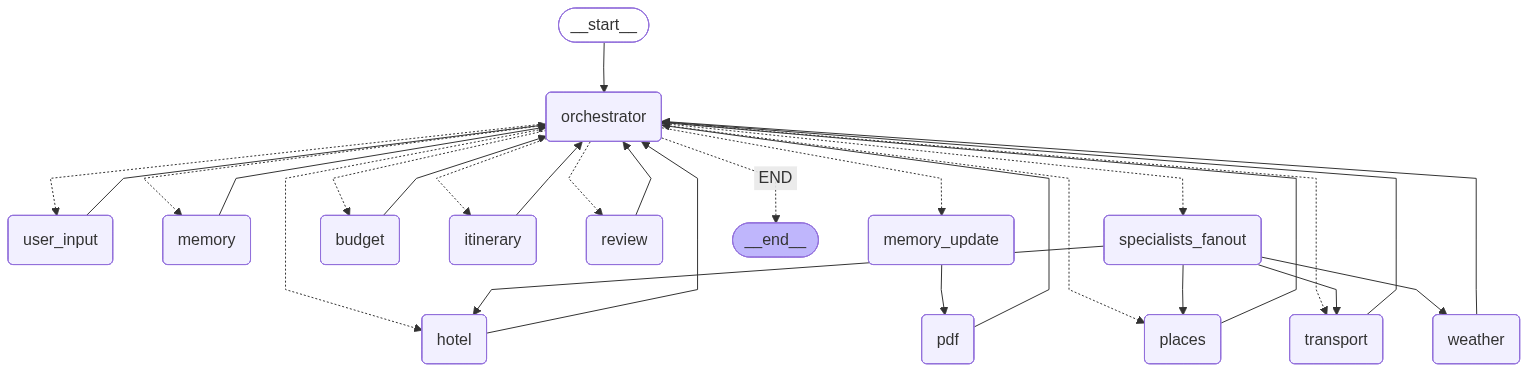

[OK] Saved trip_planner_graph.png


In [45]:
def render_workflow():
    # 1) Try mermaid PNG (needs internet)
    try:
        png = app.get_graph().draw_mermaid_png()
        with open("trip_planner_graph.png", "wb") as f:
            f.write(png)
        from IPython.display import Image, display
        display(Image(png))
        print("[OK] Saved trip_planner_graph.png")
        return
    except Exception as e:
        print("Mermaid render unavailable:", str(e)[:120])
    # 2) Try ASCII (needs grandalf: pip install grandalf)
    try:
        print(app.get_graph().draw_ascii())
        return
    except Exception as e:
        print("ASCII render unavailable:", str(e)[:120])
    # 3) Always-works fallback — print nodes + edges
    g_ = app.get_graph()
    print("Nodes:", [n for n in g_.nodes])
    print("Edges:")
    for e in g_.edges:
        print(" ", e.source, "->", e.target, ("[cond]" if e.conditional else ""))

render_workflow()


## 10 · Demo Run — the sample query from the assignment

> *Plan a 5-day Goa trip from Bangalore for a couple. Budget: ₹30,000. Need: beach resort, nightlife, sightseeing, seafood, flight preferred.*


In [46]:
SAMPLE_QUERY = ("Plan a 5-day Goa trip from Bangalore for a couple. "
                "Budget Rs 30000. Need beach resort, nightlife, sightseeing, seafood, flight preferred.")

initial_state: TripState = {
    "user_id": "demo_user",
    "thread_id": "thread_demo_001",
    "raw_query": SAMPLE_QUERY,
    "trip_preferences": {
        "source": "Bangalore",
        "destination": "Goa",
        "start_date": "2026-06-10",
        "days": 5,
        "travelers": 2,
        "travel_type": "couple",
        "budget": 30000,
        "mode_pref": "flight",
        "vibe": "mid",
        "interests": ["beach", "nightlife", "heritage"],
        "food_pref": "seafood",
    },
    "messages": [],
    "retry_count": 0,
}

# Stream so we can watch the orchestrator's decisions
final_state = None
for step, update in enumerate(app.stream(initial_state,
                                         config={"configurable": {"thread_id": "thread_demo_001"},
                                                 "recursion_limit": 50})):
    for node, payload in update.items():
        print(f"[step {step:02d}] {node:20s} →", end=" ")
        if "orchestrator_decision" in payload:
            print("decision:", payload["orchestrator_decision"])
        elif "pdf_status" in payload:
            print("PDF:", payload["pdf_status"]["path"])
        else:
            ks = list(payload.keys())[:3]
            print("updated keys:", ks)
    final_state = update

print("\nDone.")


[step 00] orchestrator         → decision: {'next': 'memory', 'reason': 'Need to recall user prefs.'}
[step 01] memory               → updated keys: ['user_profile', 'messages']
[step 02] orchestrator         → decision: {'next': 'specialists_fanout', 'reason': 'Gathering data in parallel.'}
[step 03] specialists_fanout   → updated keys: ['messages']
[step 04] hotel                → updated keys: ['hotel_data']
[step 05] places               → updated keys: ['places_data']
[step 06] transport            → updated keys: ['transport_data']
[step 07] weather              → updated keys: ['weather_data']
[step 08] orchestrator         → decision: {'next': 'budget', 'reason': 'All specialists in — compute budget.'}
[step 09] budget               → updated keys: ['budget_summary']
[step 10] orchestrator         → decision: {'next': 'itinerary', 'reason': 'Build day-wise plan.'}
[step 11] itinerary            → updated keys: ['itinerary']
[step 12] orchestrator         → decision: {'next': 'r

## 11 · Inspect the result

In [47]:
snap = app.get_state(config={"configurable": {"thread_id": "thread_demo_001"}}).values

print("Headline :", snap["itinerary"]["headline"])
print("Hotel    :", snap["hotel_data"]["top_pick"]["name"])
print("Transport:", snap["transport_data"]["recommended"]["provider"], "₹",
      snap["transport_data"]["recommended"]["price"])
print("Total    : ₹", snap["budget_summary"]["total"])
print("Target   : ₹", snap["budget_summary"]["target"])
print("Approved :", snap["review_status"]["approved"])
print("Issues   :", snap["review_status"]["issues"])
print("PDF      :", snap["pdf_status"]["path"])


Headline : A relaxed 5-day couple's beach trip to Goa with seafood and nightlife.
Hotel    : Backwoods Hostel
Transport: IndiGo ₹ 4500
Total    : ₹ 26800
Target   : ₹ 30000
Approved : True
Issues   : []
PDF      : c:\Users\kavin.k\Desktop\FDE Trainer Github\New folder\trip_report.pdf


### Open the PDF
Click the link above (or open `trip_report.pdf` from the file browser). You should see all six sections populated.


## 12 · Try your own trip

Edit the dict below and re-run. The same graph, same agents, different inputs. Notice how the memory store now contains your previous trip — re-running gives the orchestrator more context.


In [48]:
your_trip: TripState = {
    "user_id": "iyal",
    "thread_id": "thread_yours_002",
    "trip_preferences": {
        "source": "Madurai",
        "destination": "Bangalore",
        "start_date": "2026-10-20",
        "days": 4,
        "travelers": 1,
        "travel_type": "single",
        "budget": 100000,
        "mode_pref": "any",
        "vibe": "luxury",
        "interests": ["nature", "party"],
        "food_pref": "non vegetarian",
    },
    "messages": [],
    "retry_count": 0,
}

# Uncomment to run:
app.invoke(your_trip, config={"configurable": {"thread_id": "thread_yours_002"},
                               "recursion_limit": 50})


{'user_id': 'iyal',
 'thread_id': 'thread_yours_002',
 'messages': [{'role': 'orchestrator',
   'content': '→ memory: Need to recall user prefs.'},
  {'role': 'system', 'content': 'Memory recalled 3 item(s).'},
  {'role': 'orchestrator',
   'content': '→ specialists_fanout: Gathering data in parallel.'},
  {'role': 'system', 'content': 'Dispatching specialists in parallel.'},
  {'role': 'orchestrator',
   'content': '→ budget: All specialists in — compute budget.'},
  {'role': 'orchestrator', 'content': '→ itinerary: Build day-wise plan.'},
  {'role': 'orchestrator', 'content': '→ review: Need final review.'},
  {'role': 'orchestrator',
   'content': '→ memory_update: Approved → persist + render PDF.'},
  {'role': 'system', 'content': 'Memory updated.'},
  {'role': 'system', 'content': 'PDF written to trip_report.pdf'},
  {'role': 'orchestrator', 'content': '→ END: PDF complete — workflow done.'}],
 'trip_preferences': {'source': 'Madurai',
  'destination': 'Bangalore',
  'start_date':

## 13 · Submission checklist + bonus features

**Submit:**

1. This notebook (`Trip_Planner_Assignment.ipynb`) with all cells executed.
2. The generated `trip_report.pdf`.
3. The auto-generated `trip_planner_graph.png` (your LangGraph workflow image).
4. A short `README.md` linking to the architecture PNG in `/diagrams/`.
5. Push everything to a public GitHub repo and submit the link.

**Bonus features the assignment lists (easy wins):**

- *Dynamic replanning*: already supported — orchestrator retries on conflict. Demonstrate it by setting budget = 5000 and watching the retry loop.
- *Expense tracker*: extend `tool_budget_calculator` to break costs by category and day.
- *Weather alerts*: add a `weather_alert_agent` that runs daily on a checkpointed graph.
- *Voice planning*: pipe `SAMPLE_QUERY` through `whisper-1` for the input.
- *WhatsApp delivery*: post the PDF to a Twilio WhatsApp endpoint after generation.

Good luck — you're done.


## 14 · DeepEval Evaluation

We use **DeepEval** to measure whether the multi-agent system produces *good* outputs — not just outputs that run without errors.

| Metric | What it measures | Needs API key? |
|--------|-----------------|----------------|
| `BudgetAdherenceMetric` | Did the total cost stay within the user’s stated budget? | ❌ No |
| `PreferenceMatchMetric` | Did the itinerary cover the user’s stated interests? | ❌ No |
| `ItineraryCompletenessMetric` | Correct day count + headline + hotel + transport? | ❌ No |
| `ReviewApprovalMetric` | Did `final_review_agent` approve the plan with zero issues? | ❌ No |
| `AnswerRelevancyMetric` | Is the itinerary relevant to the original query? | ✅ Yes (OpenAI) |
| `FaithfulnessMetric` | Does output stay faithful to retrieved data (no hallucinations)? | ✅ Yes (OpenAI) |

> **Rule-based metrics (1–4) always run.** LLM-based metrics (5–6) are skipped if `OPENAI_API_KEY` is not set.


In [51]:
from deepeval.test_case import LLMTestCase
from deepeval.metrics import AnswerRelevancyMetric, FaithfulnessMetric
from deepeval.metrics.base_metric import BaseMetric


# ── Custom Metric 1: Budget Adherence ────────────────────────────────────────
class BudgetAdherenceMetric(BaseMetric):
    """Passes if the total cost does not exceed the user's stated budget."""
    def __init__(self):
        self.name = 'Budget Adherence'
        self.threshold = 1.0
        self.score = 0.0
        self.reason = ''
        self.success = False

    def measure(self, test_case: LLMTestCase) -> float:
        meta   = test_case.additional_metadata or {}
        total  = meta.get('total_cost', 0)
        target = meta.get('target_budget', 1)
        if target <= 0:
            self.score, self.reason = 0.0, 'Target budget is zero or missing.'
        elif total <= target:
            self.score  = 1.0
            self.reason = f'\u2713 Under budget: \u20b9{total:,} <= \u20b9{target:,}'
        else:
            over_pct    = (total - target) / target * 100
            self.score  = max(0.0, 1.0 - over_pct / 100)
            self.reason = f'\u2717 Over budget by {over_pct:.1f}%: \u20b9{total:,} > \u20b9{target:,}'
        self.success = self.score >= self.threshold
        return self.score

    async def a_measure(self, test_case: LLMTestCase, *args, **kwargs) -> float:
        return self.measure(test_case)

    def is_successful(self) -> bool:
        return self.success


# ── Custom Metric 2: Preference Match ────────────────────────────────────────
class PreferenceMatchMetric(BaseMetric):
    """Checks what fraction of the user's interests appear in the itinerary output."""
    def __init__(self, threshold: float = 0.5):
        self.name = 'Preference Match'
        self.threshold = threshold
        self.score = 0.0
        self.reason = ''
        self.success = False

    def measure(self, test_case: LLMTestCase) -> float:
        meta      = test_case.additional_metadata or {}
        interests = meta.get('interests', [])
        output    = (test_case.actual_output or '').lower()
        if not interests:
            self.score, self.reason, self.success = 1.0, 'No interests specified.', True
            return self.score
        matched = [i for i in interests if i.lower() in output]
        self.score  = len(matched) / len(interests)
        missing     = list(set(interests) - set(matched))
        self.reason = f'Matched {len(matched)}/{len(interests)}: {matched}' + (f' | Missing: {missing}' if missing else '')
        self.success = self.score >= self.threshold
        return self.score

    async def a_measure(self, test_case: LLMTestCase, *args, **kwargs) -> float:
        return self.measure(test_case)

    def is_successful(self) -> bool:
        return self.success


# ── Custom Metric 3: Itinerary Completeness ──────────────────────────────────
class ItineraryCompletenessMetric(BaseMetric):
    """Checks day count, headline, hotel, and transport are all present."""
    def __init__(self, threshold: float = 1.0):
        self.name = 'Itinerary Completeness'
        self.threshold = threshold
        self.score = 0.0
        self.reason = ''
        self.success = False

    def measure(self, test_case: LLMTestCase) -> float:
        meta   = test_case.additional_metadata or {}
        checks = {
            'correct day count':  meta.get('expected_days', -1) == meta.get('actual_days', -2),
            'headline present':   meta.get('has_headline', False),
            'hotel selected':     meta.get('has_hotel', False),
            'transport selected': meta.get('has_transport', False),
        }
        passed      = sum(checks.values())
        self.score  = passed / len(checks)
        failed      = [k for k, v in checks.items() if not v]
        self.reason = f'{passed}/{len(checks)} checks passed.' + (f' Failed: {failed}' if failed else ' All OK \u2713')
        self.success = self.score >= self.threshold
        return self.score

    async def a_measure(self, test_case: LLMTestCase, *args, **kwargs) -> float:
        return self.measure(test_case)

    def is_successful(self) -> bool:
        return self.success


# ── Custom Metric 4: Review Approval ─────────────────────────────────────────
class ReviewApprovalMetric(BaseMetric):
    """Passes if final_review_agent approved the plan with zero issues."""
    def __init__(self):
        self.name = 'Review Approval'
        self.threshold = 1.0
        self.score = 0.0
        self.reason = ''
        self.success = False

    def measure(self, test_case: LLMTestCase) -> float:
        meta     = test_case.additional_metadata or {}
        approved = meta.get('approved', False)
        issues   = meta.get('issues', [])
        if approved and not issues:
            self.score, self.reason = 1.0, '\u2713 Approved with no issues.'
        elif approved:
            self.score, self.reason = 0.7, f'Approved with {len(issues)} issue(s): {issues}'
        else:
            self.score, self.reason = 0.0, f'\u2717 Not approved. Issues: {issues}'
        self.success = self.score >= self.threshold
        return self.score

    async def a_measure(self, test_case: LLMTestCase, *args, **kwargs) -> float:
        return self.measure(test_case)

    def is_successful(self) -> bool:
        return self.success


print('\u2713 4 custom DeepEval metrics defined (no API key required).')
print('  1. BudgetAdherenceMetric        - total cost vs. stated budget')
print('  2. PreferenceMatchMetric         - interests covered in itinerary')
print('  3. ItineraryCompletenessMetric   - days + headline + hotel + transport')
print('  4. ReviewApprovalMetric          - final_review_agent approved?')


ImportError: cannot import name 'InvalidSchemaError' from 'pydantic._internal._generate_schema' (c:\Users\kavin.k\AppData\Local\Programs\Python\Python313\Lib\site-packages\pydantic\_internal\_generate_schema.py)

In [ ]:
# ── Build LLMTestCase objects from the executed workflow states ───────────────
snap  = app.get_state(config={'configurable': {'thread_id': 'thread_demo_001'}}).values
snap2 = app.get_state(config={'configurable': {'thread_id': 'thread_yours_002'}}).values


def build_test_case(snap, label):
    prefs  = snap['trip_preferences']
    it     = snap['itinerary']
    budget = snap['budget_summary']
    review = snap['review_status']
    hotel  = snap['hotel_data']
    trans  = snap['transport_data']
    places = snap['places_data']

    # Human-readable output string for LLM-based metrics
    actual_output = (
        f"Headline: {it['headline']}\n\n"
        + '\n'.join(
            f"Day {d['day']}: Morning={d['morning']}, Afternoon={d['afternoon']}, Evening={d['evening']}"
            for d in it['days']
        )
        + f"\n\nHotel: {hotel['top_pick']['name']} ({hotel['top_pick']['stars']}\u2605, "
          f"\u20b9{hotel['top_pick']['price']:,}/night)"
        + f"\nTransport: {trans['recommended']['provider']} "
          f"({trans['recommended']['mode']}, \u20b9{trans['recommended']['price']:,})"
        + f"\nTotal: \u20b9{budget['total']:,}  |  Budget: \u20b9{budget['target']:,}"
    )

    # Retrieval context = what the agents actually fetched from tools / memory
    retrieval_context = [
        f"Weather summary: {snap['weather_data']['summary']}",
        f"Hotels available: {[h['name'] for h in hotel['candidates']]}",
        f"Transport options: {[o['provider'] + ' (' + o['mode'] + ')' for o in trans['options']]}",
        f"Attractions: {[p['name'] for p in places['attractions']]}",
        f"Memory recalled: {snap['user_profile']['recalled']}",
    ]

    return LLMTestCase(
        input=snap.get('raw_query', f"{prefs['days']}-day trip to {prefs['destination']}"),
        actual_output=actual_output,
        retrieval_context=retrieval_context,
        additional_metadata={
            'total_cost':     budget['total'],
            'target_budget':  budget['target'],
            'interests':      prefs['interests'],
            'expected_days':  prefs['days'],
            'actual_days':    len(it['days']),
            'has_headline':   bool(it.get('headline')),
            'has_hotel':      hotel.get('top_pick') is not None,
            'has_transport':  bool(trans.get('recommended')),
            'approved':       review['approved'],
            'issues':         review['issues'],
        }
    )


tc_demo  = build_test_case(snap,  'TC-1 Goa trip')
tc_yours = build_test_case(snap2, 'TC-2 Your trip')

print('Test cases built successfully:')
print(f"  TC-1 (Goa  ): input='{tc_demo.input[:70]}...'")
print(f"  TC-2 (Yours): input='{tc_yours.input[:70]}...'")


In [ ]:
# ── Run all 4 rule-based metrics on both test cases ───────────────────────────
from tabulate import tabulate

test_cases = [
    ('TC-1  Goa trip',  tc_demo),
    ('TC-2  Your trip', tc_yours),
]

rows = []
overall_pass = True

for tc_name, tc in test_cases:
    for MetricClass, kwargs in [
        (BudgetAdherenceMetric,       {}),
        (PreferenceMatchMetric,       {'threshold': 0.5}),
        (ItineraryCompletenessMetric, {'threshold': 1.0}),
        (ReviewApprovalMetric,        {}),
    ]:
        m     = MetricClass(**kwargs)
        score = m.measure(tc)
        passed = m.is_successful()
        overall_pass = overall_pass and passed
        rows.append([
            tc_name,
            m.name,
            f'{score:.2f}',
            f'{m.threshold:.2f}',
            'PASS \u2705' if passed else 'FAIL \u274c',
            (m.reason[:55] + '...') if len(m.reason) > 55 else m.reason,
        ])

headers = ['Test Case', 'Metric', 'Score', 'Thresh', 'Result', 'Reason']
print(tabulate(rows, headers=headers, tablefmt='rounded_outline'))
print()
print('Overall:', '\u2705 ALL PASSED' if overall_pass else '\u26a0\ufe0f  SOME METRICS FAILED')


In [ ]:
# ── (Optional) LLM-based metrics — requires OPENAI_API_KEY ───────────────────
# DeepEval uses GPT as a judge to score Answer Relevancy and Faithfulness.
if USE_REAL_LLM:
    from deepeval import evaluate
    print('Running LLM-based metrics via OpenAI...')
    evaluate(
        test_cases=[tc_demo, tc_yours],
        metrics=[
            AnswerRelevancyMetric(threshold=0.7),
            FaithfulnessMetric(threshold=0.7),
        ]
    )
else:
    print('OPENAI_API_KEY not set — LLM-based metrics skipped.')
    print('Set it in your environment and re-run this cell to enable:\n')
    print('  Metric               Threshold  What it checks')
    print('  AnswerRelevancyMetric   0.70     Is the itinerary relevant to the query?')
    print('  FaithfulnessMetric      0.70     Does output use only retrieved data (no hallucinations)?')
